# 2026 Projection Holdout Evaluation V1

Evaluate the persisted V5 projection model on the original time-based training holdout set.

Plan:

1. Load the persisted model run and feature contract.
2. Load the V5 training SQL extracts, not the inference SQLs.
3. Rebuild V5 loan/installment/Stage C bases with the persisted feature contract.
4. Score the holdout loans and compare predicted final payin to actual realized payin.
5. Review portfolio metrics plus loan-level and monthly calibration plots.

This notebook does not retrain models.

In [1]:
# Configuration
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'util').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Set RUN_TAG to a specific folder name like "20260429T212208Z".
# Leave as None to load the newest persisted run.
RUN_TAG = None

# V5 training evaluation uses the same maturity rule as training.
MIN_LOAN_AGE_DAYS = 120

SQL_PATH = project_root / 'sql_scripts' / 'jcx_raw_harvey_v14.sql'
PAYMENT_SQL_PATH = project_root / 'sql_scripts' / 'SP_payment_data_v1.sql'
ENV_PATH = project_root / '.env'

print('project_root:', project_root)
print('raw training SQL:', SQL_PATH.name)
print('payment training SQL:', PAYMENT_SQL_PATH.name)
print('min loan age days:', MIN_LOAN_AGE_DAYS)

project_root: /Users/starsrain/2025_concord/yieldCurve_augmenting
raw training SQL: jcx_raw_harvey_v14.sql
payment training SQL: SP_payment_data_v1.sql
min loan age days: 120


In [2]:
# Load persisted model run.
from util.projection_model_persistence import load_projection_run

runs_root = project_root / 'prediction_models' / 'runs'
if RUN_TAG is None:
    run_dirs = sorted([p for p in runs_root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f'No persisted runs found under {runs_root}')
    RUN_TAG = run_dirs[-1].name

model_run = load_projection_run(project_root, RUN_TAG)
if not model_run.feature_contract.get('category_maps'):
    print('WARNING: this run has no persisted category_maps. Rerun the final V5 persistence cell before relying on this evaluation.')

created_at = pd.to_datetime(model_run.metadata.get('created_at_utc'), errors='coerce')
if pd.notna(created_at):
    EVALUATION_AS_OF_DATE = created_at.tz_convert(None).normalize() if created_at.tzinfo else created_at.normalize()
else:
    EVALUATION_AS_OF_DATE = pd.Timestamp.today().normalize()

print('loaded run:', model_run.run_dir)
print('model version:', model_run.metadata.get('model_version'))
print('evaluation as-of date:', EVALUATION_AS_OF_DATE.date())
print('class order:', model_run.feature_contract.get('class_order'))
print('stage_a features:', len(model_run.feature_contract.get('stage_a_features', [])))
print('stage_b features:', len(model_run.feature_contract.get('stage_b_features', [])))
print('stage_c features:', len(model_run.feature_contract.get('stage_c_recovery_features', [])))

loaded run: /Users/starsrain/2025_concord/yieldCurve_augmenting/prediction_models/runs/20260429T212208Z
model version: projection_v5
evaluation as-of date: 2026-04-29
class order: ['FPD', 'SPD', 'TPD', 'LatePD', 'Clean']
stage_a features: 14
stage_b features: 33
stage_c features: 59


In [3]:
# Load original V5 training extracts.
from util.db import create_db_engine
from util.sql_loader import read_sql_file
from util.sql_runner import execute_sql_and_read_result_sets, execute_sql_and_read_temp_table

engine = create_db_engine(ENV_PATH)
raw_df = execute_sql_and_read_temp_table(engine, read_sql_file(SQL_PATH), '#t17_combined')
payment_sets = execute_sql_and_read_result_sets(engine, read_sql_file(PAYMENT_SQL_PATH), max_sets=3)
payment_normal_df = payment_sets[0] if len(payment_sets) > 0 else pd.DataFrame()
payment_arr_df = payment_sets[1] if len(payment_sets) > 1 else pd.DataFrame()
payment_3p_df = payment_sets[2] if len(payment_sets) > 2 else pd.DataFrame()

print('raw_df shape:', raw_df.shape)
print('raw_df loans:', raw_df['LoanID'].nunique())
print('payment_normal_df shape:', payment_normal_df.shape)
print('payment_arr_df shape:', payment_arr_df.shape)
print('payment_3p_df shape:', payment_3p_df.shape)

raw_df shape: (1014335, 33)
raw_df loans: 199728
payment_normal_df shape: (1662733, 17)
payment_arr_df shape: (66477, 18)
payment_3p_df shape: (32671, 18)


In [4]:
# Score persisted model on V5 holdout.
import importlib

import util.projection_evaluation as _peval
importlib.reload(_peval)

from util.projection_evaluation import score_holdout_projection

results = score_holdout_projection(
    model_run=model_run,
    raw_df=raw_df,
    payment_normal_df=payment_normal_df,
    payment_arr_df=payment_arr_df,
    payment_3p_df=payment_3p_df,
    min_loan_age_days=MIN_LOAN_AGE_DAYS,
    evaluation_as_of_date=EVALUATION_AS_OF_DATE,
)

eval_df = results['eval_df']
monthly = results['monthly']
metrics = results['metrics']
portfolio_ci = results['portfolio_ci']

print('holdout loans:', len(eval_df))
print('holdout originated amount:', f"{metrics['originated_amount']:,.0f}")
print('portfolio actual payin:', f"{metrics['portfolio_actual_payin']:.4f}")
print('portfolio predicted payin:', f"{metrics['portfolio_predicted_payin']:.4f}")
print('portfolio error:', f"{metrics['portfolio_error']:.4f}")
print('portfolio MC 90% CI:', f"[{metrics['portfolio_p05']:.4f}, {metrics['portfolio_p95']:.4f}]")

holdout loans: 35997
holdout originated amount: 28,992,970
portfolio actual payin: 1.3903
portfolio predicted payin: 1.2390
portfolio error: -0.1513
portfolio MC 90% CI: [1.2320, 1.2459]


## Portfolio Metrics

The portfolio line is dollar-weighted by originated amount. Positive error means the model over-predicted final realized payin.

In [5]:
pd.Series(metrics).to_frame('value')

,value
loans,3.599700e+04
originated_amount,2.899297e+07
mae,6.151285e-01
rmse,7.790584e-01
weighted_mae,6.316965e-01
portfolio_actual_payin,1.390308e+00
portfolio_predicted_payin,1.239016e+00
portfolio_error,-1.512921e-01
portfolio_p05,1.231956e+00
portfolio_p95,1.245899e+00


## Monthly Calibration

This is the main stakeholder view: by origination month, compare actual final realized payin with the model's predicted final payin on the holdout loans.

In [6]:
monthly

,origination_month,loans,originated_amount,actual_payin,predicted_payin,error,mae,weighted_mae
0,2025-04,4728,3854860.0,1.410934,1.180511,-0.230423,0.654169,0.671760
1,2025-05,5017,4099500.0,1.389916,1.230656,-0.159260,0.642828,0.663535
2,2025-06,4678,3868225.0,1.393600,1.231477,-0.162123,0.641899,0.652515
3,2025-07,4367,3587400.0,1.426655,1.253550,-0.173105,0.632221,0.651439
4,2025-08,3951,3155350.0,1.465868,1.307585,-0.158284,0.599240,0.618016
5,2025-09,3621,2819975.0,1.418752,1.269496,-0.149255,0.602705,0.616494
6,2025-10,3644,2777760.0,1.358485,1.251433,-0.107052,0.585435,0.600384
7,2025-11,2763,2260650.0,1.309662,1.232593,-0.077069,0.559684,0.577709
8,2025-12,3228,2569250.0,1.285627,1.205752,-0.079876,0.567338,0.576718


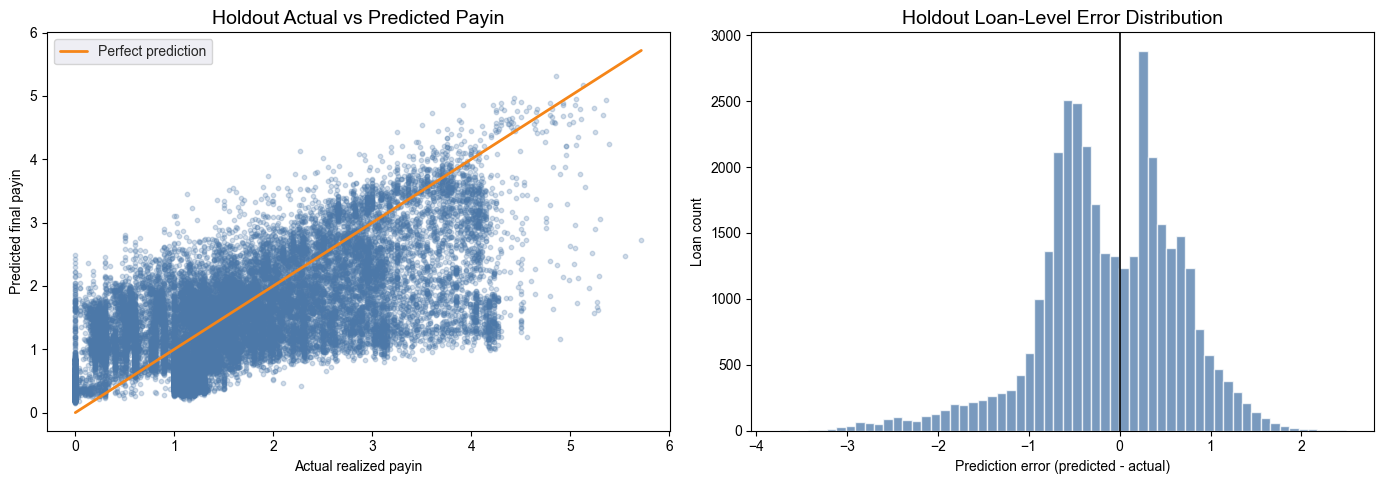

In [7]:
from util.projection_evaluation import (
    plot_actual_vs_predicted,
    plot_error_distribution,
    plot_monthly_actual_vs_predicted,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_actual_vs_predicted(eval_df, ax=axes[0])
plot_error_distribution(eval_df, ax=axes[1])
plt.tight_layout()
plt.show()

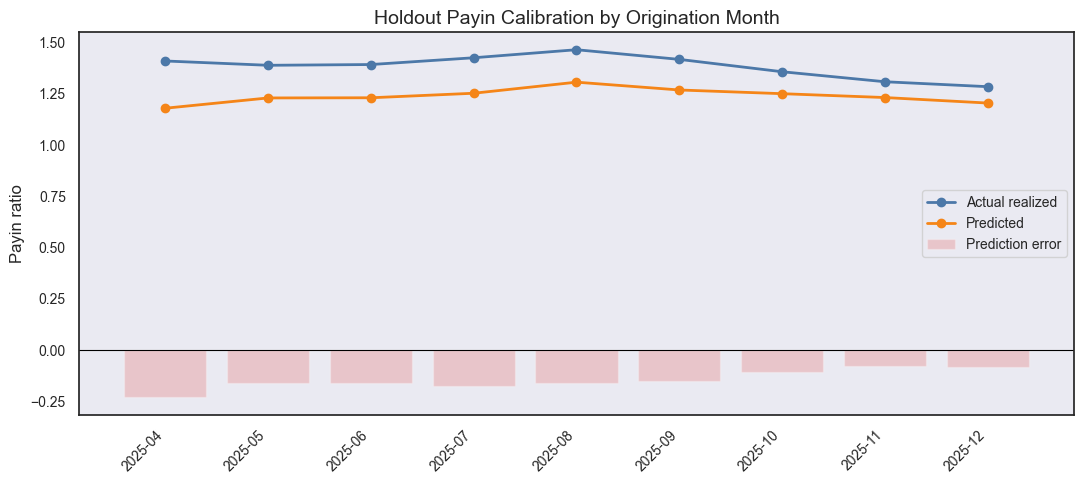

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_monthly_actual_vs_predicted(monthly, ax=ax)
plt.tight_layout()
plt.show()

## Largest Loan-Level Misses

Use this only as a diagnostic slice. Large misses can be normal for individual loans because the model is designed primarily for cohort/portfolio payin, but repeated patterns here can point to feature or segmentation gaps.

In [9]:
display_cols = [
    'LoanID', 'origination_month', 'OriginatedAmount',
    'actual_payin', 'predicted_payin', 'prediction_error', 'abs_error',
    'P_FPD', 'P_SPD', 'P_TPD', 'P_LatePD', 'P_Clean',
]
eval_df.sort_values('abs_error', ascending=False)[display_cols].head(25)

,LoanID,origination_month,OriginatedAmount,actual_payin,predicted_payin,prediction_error,abs_error,P_FPD,P_SPD,P_TPD,P_LatePD,P_Clean
2670,I2324332-0,2025-04,800.0,4.893750,1.156153,-3.737597,3.737597,0.340567,0.151673,0.108061,0.263401,0.136298
6119,I2348008-0,2025-05,600.0,5.241667,1.570726,-3.670940,3.670940,0.250468,0.202871,0.107507,0.243708,0.195446
1470,I2315856-0,2025-04,1000.0,5.275000,1.624928,-3.650072,3.650072,0.226825,0.157454,0.114976,0.288759,0.211987
9213,I2370420-0,2025-05,800.0,5.268750,1.663078,-3.605672,3.605672,0.195117,0.138479,0.112618,0.327417,0.226369
4428,I2337084-0,2025-05,800.0,5.272550,1.744821,-3.527729,3.527729,0.197453,0.143895,0.112544,0.318408,0.227701
2130,I2320091-0,2025-04,800.0,4.562500,1.188198,-3.374302,3.374302,0.293723,0.199878,0.091398,0.269895,0.145106
3233,I2328516-0,2025-04,600.0,5.066667,1.737837,-3.328829,3.328829,0.218098,0.149192,0.102014,0.306899,0.223797
15518,I2403041-0,2025-07,1000.0,4.499920,1.268659,-3.231261,3.231261,0.256067,0.192193,0.101688,0.260168,0.189884
317,I2307966-0,2025-04,600.0,5.191667,1.963567,-3.228100,3.228100,0.208805,0.196147,0.111812,0.258452,0.224783
2925,I2326067-0,2025-04,1000.0,4.235000,1.012036,-3.222964,3.222964,0.358313,0.162007,0.096032,0.239688,0.143961
